In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile

zip_path = "/content/sample_data/faces.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/sample_data")

In [ ]:
!pip install timm torch torchvision

In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_dir = "/content/sample_data/faces/train"
img_size = 224
batch_size = 32
num_epochs = 10
lr = 1e-4

Device: cpu


In [ ]:
import os
import shutil
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

img_size = 224
batch_size = 32

data_dir = "/content/sample_data/faces/train"

junk_folders = [".ipynb_checkpoints", "__MACOSX"]

for jf in junk_folders:
    jf_path = os.path.join(data_dir, jf)
    if os.path.isdir(jf_path):
        print(f"Removing junk folder: {jf_path}")
        shutil.rmtree(jf_path)

print("Subfolders in data_dir:", os.listdir(data_dir))

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(
    root=data_dir,
    transform=train_transform
)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_ds, val_ds = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

val_ds.dataset.transform = val_transform

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
print("Classes:", class_names)
print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))

images, labels = next(iter(train_loader))
print("One batch shape:", images.shape, "Labels shape:", labels.shape)

Subfolders in data_dir: ['ASD', 'Non_ASD']
Classes: ['ASD', 'Non_ASD']
Train samples: 2028
Val samples: 508
One batch shape: torch.Size([32, 3, 224, 224]) Labels shape: torch.Size([32])


In [ ]:
num_classes = 2

model = timm.create_model(
    'vit_base_patch16_224',
    pretrained=True
)

# Replace the classification head
in_features = model.head.in_features
model.head = nn.Linear(in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)          # shape: [batch, 2]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
best_val_acc = 0.0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}  Val   Acc: {val_acc:.4f}")

    # save best model (runtime + Google Drive)
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        # Save locally (runtime)
        torch.save(model.state_dict(), "vit_asd_best.pth")

        # Save a copy in Google Drive (permanent)
        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/vit_asd_best.pth"
        )

        print("  -> Saved best model (runtime + Google Drive)")

print("Best val acc:", best_val_acc)


Epoch 1/10
  Train Loss: 0.6622  Train Acc: 0.6815
  Val   Loss: 0.4828  Val   Acc: 0.7657
  -> Saved best model (runtime + Google Drive)
Epoch 2/10
  Train Loss: 0.4087  Train Acc: 0.8161
  Val   Loss: 0.7195  Val   Acc: 0.7244
Epoch 3/10
  Train Loss: 0.2591  Train Acc: 0.8876
  Val   Loss: 0.6866  Val   Acc: 0.7815
  -> Saved best model (runtime + Google Drive)
Epoch 4/10
  Train Loss: 0.1557  Train Acc: 0.9374
  Val   Loss: 0.6788  Val   Acc: 0.7992
  -> Saved best model (runtime + Google Drive)
Epoch 5/10
  Train Loss: 0.0892  Train Acc: 0.9670
  Val   Loss: 0.7074  Val   Acc: 0.7992
Epoch 6/10
  Train Loss: 0.0991  Train Acc: 0.9615
  Val   Loss: 0.4101  Val   Acc: 0.8110
  -> Saved best model (runtime + Google Drive)
Epoch 7/10
  Train Loss: 0.1007  Train Acc: 0.9630
  Val   Loss: 0.6502  Val   Acc: 0.7913
Epoch 8/10
  Train Loss: 0.0519  Train Acc: 0.9793
  Val   Loss: 0.9629  Val   Acc: 0.7913
Epoch 9/10
  Train Loss: 0.0487  Train Acc: 0.9852
  Val   Loss: 0.7836  Val   Acc: 

In [ ]:
# == Evaluation script: load model from Drive and evaluate on test set ==
# Paste into a new notebook cell and run.

# 1) Mount Drive (skip if already mounted)
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 2) Config - change these if your paths differ
DRIVE_MODEL_PATH = "/content/drive/MyDrive/vit_asd_best.pth"   # path to your saved .pth in Drive
TEST_DIR = "/content/sample_data/faces/test"                     # folder with ASD/ NonASD subfolders
MODEL_NAME = "vit_base_patch16_224"                          # timm model you used
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 2


In [ ]:
# 3) Imports
import os
import torch
import timm
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Model path:", DRIVE_MODEL_PATH)
print("Test folder:", TEST_DIR)



Using device: cpu
Model path: /content/drive/MyDrive/vit_asd_best.pth
Test folder: /content/sample_data/faces/test


In [ ]:
# 4) Basic checks
if not os.path.exists(DRIVE_MODEL_PATH):
    raise FileNotFoundError(f"Model file not found at {DRIVE_MODEL_PATH} - check path")
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"Test directory not found at {TEST_DIR} - check path")


In [ ]:
# 5) Transforms & dataset
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

# Use ImageFolder for test data: folder structure TEST_DIR/ClassName/images...
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=test_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Found test classes:", test_dataset.classes)
print("Number of test samples:", len(test_dataset))


Found test classes: ['ASD', 'Non_ASD']
Number of test samples: 300


In [ ]:
# 6) Build model architecture and load weights
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)

# load state dict (handle possible DataParallel 'module.' prefix)
state = torch.load(DRIVE_MODEL_PATH, map_location=device)
if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    # strip "module." if present
    new_state = {k.replace("module.", ""): v for k, v in state.items()}
    model.load_state_dict(new_state)
else:
    try:
        model.load_state_dict(state)
    except RuntimeError:
        # maybe the checkpoint is a dict with keys (epoch, model_state_dict, ...)
        if 'model_state_dict' in state:
            model.load_state_dict(state['model_state_dict'])
        else:
            raise

model.to(device)
model.eval()
print("Model loaded and set to eval()")


Model loaded and set to eval()


In [ ]:
# 7) Run evaluation
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)                    # shape [B, num_classes]
        probs = torch.softmax(outputs, dim=1)    # probabilities
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().cpu().numpy())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



Test Accuracy: 0.8533

Classification report:
              precision    recall  f1-score   support

         ASD       0.84      0.87      0.86       150
     Non_ASD       0.86      0.84      0.85       150

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

Confusion matrix:
 [[130  20]
 [ 24 126]]
ROC AUC: 0.9237


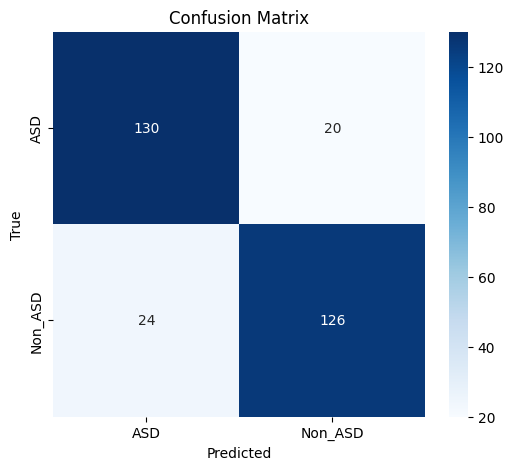

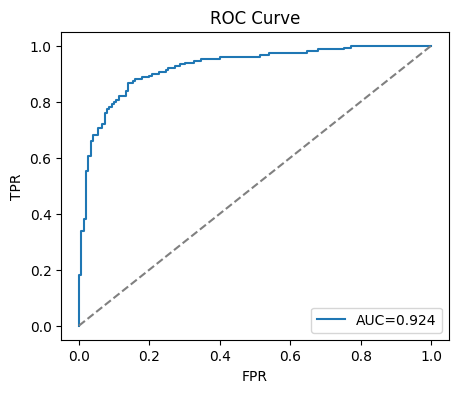

In [ ]:
# 8) Metrics
acc = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {acc:.4f}\n")
print("Classification report:")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:\n", cm)

# 9) ROC AUC (binary)
if NUM_CLASSES == 2:
    try:
        auc = roc_auc_score(all_labels, all_probs[:,1])
        print(f"ROC AUC: {auc:.4f}")
    except Exception as e:
        print("Could not compute AUC:", e)

# 10) Plots: confusion matrix + ROC curve
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=test_dataset.classes, yticklabels=test_dataset.classes, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.show()

if NUM_CLASSES == 2:
    try:
        fpr, tpr, _ = roc_curve(all_labels, all_probs[:,1])
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0,1],[0,1],'--', color='gray')
        plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend()
        plt.show()
    except Exception as e:
        pass


In [ ]:
# 11) Save predictions CSV for debugging (optional)
import csv
out_csv = "test_predictions_from_drive.csv"
with open(out_csv, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["filepath", "true_label", "pred_label", "pred_confidence"])
    for i, (path, true_idx) in enumerate(test_dataset.samples):
        pred_idx = int(all_preds[i])
        conf = float(np.max(all_probs[i]))
        writer.writerow([path, test_dataset.classes[true_idx], test_dataset.classes[pred_idx], conf])
print("Saved predictions to",out_csv)

NameError: name 'test_dataset' is not defined